# Machine and Deep Learning for DDoS Detection
### Marcos V. O. Assis (mvoassis@gmail.com)
***

> ## Published Results:

* *A GRU deep learning system against attacks in software defined networks*

* https://doi.org/10.1016/j.jnca.2020.102942



* \***Update - 06/2022** - improved detection results through better data cleaning process. Updated results on Git. 

> ## Objectives

1. Evaluate different Machine and Deep Learning methods for anomaly detection.
2. Detection of Distributed Denial of Service Attacks

> ## Dataset

* CIC-DDoS2019 - https://www.unb.ca/cic/datasets/ddos-2019.html

> ## Evaluated Methods

* Gated Recurrent Units (GRU)
* Long-Short Term Memory (LSTM)
* Convolutional Neural Network (CNN)
* Deep Neural Network (DNN)
* Support Vector Machine (SVM)
* Logistic Regression (LR)
* Gradient Descent (GD)
* k Nearest Neighbors (kNN)

> ## Environment Config.

* Python 3.7.13
* Numpy 1.16.4
* Scikit-learn 0.21.2
* Pandas 0.24.2
* Tensorflow 1.14.0
* Keras 2.2.4
* Matplotlib 3.1.0
* Seaborn 0.11.2

***

# Importing and treating CIC-DDoS-2019

In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
from sklearn import preprocessing

## Defining functions to load files and downsample them

As this research aims to develop a binary detector (Attack or Normal), we should balance the dataset between these two classes. However, CIC-DDOS2019 has few normal flows in it. Thus, downsampling is necessary.

For the downsampling process, we allow anomalous flows to be "mult" times bigger than normal flows. This approach aims to reduce class disbalance while preventing information losses on attack flows (when the number of attack flows is downsampled to the number of normal ones, ML models could not fit appropriately).  

In [2]:
import pandas as pd
import random
from sklearn.utils import resample

mult = 5
num_samples = 5000  # Variable to control the number of rows to read

def load_file(path):
    # Count total lines in the file (excluding header)
    total_lines = sum(1 for _ in open(path)) - 1  

    # Ensure at most `num_samples` rows are read randomly
    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None  # Read entire file if it's smaller than `num_samples`

    data = pd.read_csv(path, skiprows=skip_rows, sep=',', low_memory=False)

    is_benign = data[' Label'] == 'BENIGN'
    flows_ok = data[is_benign]
    flows_ddos_full = data[~is_benign]
    
    sizeDownSample = len(flows_ok) * mult  # Target size for anomalous data
    
    # Downsample majority class
    if sizeDownSample < len(flows_ddos_full): 
        flows_ddos_reduced = resample(
            flows_ddos_full,
            replace=False,
            n_samples=sizeDownSample,
            random_state=27
        )
    else:
        flows_ddos_reduced = flows_ddos_full

    final_df = pd.concat([flows_ok, flows_ddos_reduced])

    return final_df


def load_huge_file(path):
    total_lines = sum(1 for _ in open(path)) - 1  

    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None  

    df_chunk = pd.read_csv(path, skiprows=skip_rows, chunksize=500000, low_memory=False)
    
    chunk_list_ok = []  
    chunk_list_ddos = [] 

    for chunk in df_chunk:  
        is_benign = chunk[' Label'] == 'BENIGN'
        flows_ok = chunk[is_benign]
        flows_ddos_full = chunk[~is_benign]
        
        if (len(flows_ok) * mult) < len(flows_ddos_full): 
            sizeDownSample = len(flows_ok) * mult  
            
            flows_ddos_reduced = resample(
                flows_ddos_full,
                replace=False,
                n_samples=sizeDownSample,
                random_state=27
            )
        else:
            flows_ddos_reduced = flows_ddos_full
            
        chunk_list_ok.append(flows_ok)
        chunk_list_ddos.append(flows_ddos_reduced)
        
    flows_ok = pd.concat(chunk_list_ok)
    flows_ddos = pd.concat(chunk_list_ddos)

    final_df = pd.concat([flows_ok, flows_ddos])

    return final_df


## Loading CIC-DDoS2019 - Day 1 (training)

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDPLag.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Syn.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/MSSQL.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Portmap.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/LDAP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NetBIOS.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_SSDP.csv
/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NTP.csv
/kaggle/input

In [4]:
import pandas as pd
import random
from sklearn.utils import resample

mult = 5
num_samples = 5000

def load_file(path):
    total_lines = sum(1 for _ in open(path)) - 1  

    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None

    data = pd.read_csv(path, skiprows=skip_rows, sep=',', low_memory=False)

    is_benign = data[' Label'] == 'BENIGN'
    flows_ok = data[is_benign]
    flows_ddos_full = data[~is_benign]
    
    sizeDownSample = len(flows_ok) * mult

    # Guard: kalau tidak ada BENIGN, return semua attack aja
    if sizeDownSample == 0:
        return flows_ddos_full

    if sizeDownSample < len(flows_ddos_full): 
        flows_ddos_reduced = resample(
            flows_ddos_full,
            replace=False,
            n_samples=sizeDownSample,
            random_state=27
        )
    else:
        flows_ddos_reduced = flows_ddos_full

    return pd.concat([flows_ok, flows_ddos_reduced])


def load_huge_file(path):
    total_lines = sum(1 for _ in open(path)) - 1  

    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None  

    df_chunk = pd.read_csv(path, skiprows=skip_rows, chunksize=500000, low_memory=False)
    
    chunk_list_ok = []  
    chunk_list_ddos = [] 

    for chunk in df_chunk:  
        is_benign = chunk[' Label'] == 'BENIGN'
        flows_ok = chunk[is_benign]
        flows_ddos_full = chunk[~is_benign]
        
        # Guard: kalau chunk tidak ada BENIGN
        if len(flows_ok) == 0:
            chunk_list_ddos.append(flows_ddos_full)
            continue

        if (len(flows_ok) * mult) < len(flows_ddos_full): 
            sizeDownSample = len(flows_ok) * mult  
            flows_ddos_reduced = resample(
                flows_ddos_full,
                replace=False,
                n_samples=sizeDownSample,
                random_state=27
            )
        else:
            flows_ddos_reduced = flows_ddos_full
            
        chunk_list_ok.append(flows_ok)
        chunk_list_ddos.append(flows_ddos_reduced)
        
    flows_ok = pd.concat(chunk_list_ok) if chunk_list_ok else pd.DataFrame()
    flows_ddos = pd.concat(chunk_list_ddos) if chunk_list_ddos else pd.DataFrame()

    return pd.concat([flows_ok, flows_ddos])


# ── Loading ──────────────────────────────────────────────────────────────
BASE_PATH = '/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/'

flows = load_huge_file(BASE_PATH + 'TFTP.csv')
print('file 1 loaded')

files = [
    "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", "DrDoS_NetBIOS.csv",
    "DrDoS_NTP.csv", "DrDoS_SNMP.csv", "DrDoS_SSDP.csv",
    "DrDoS_UDP.csv", "Syn.csv", "DrDoS_DNS.csv", "UDPLag.csv"
]

for i, file in enumerate(files, start=2):
    df = load_file(BASE_PATH + file)
    flows = pd.concat([flows, df], ignore_index=True)
    print(f'file {i} loaded')

flows.to_csv('/kaggle/working/export_dataframe.csv', index=False, header=True)
del flows

file 1 loaded
file 2 loaded
file 3 loaded
file 4 loaded
file 5 loaded
file 6 loaded
file 7 loaded
file 8 loaded
file 9 loaded
file 10 loaded
file 11 loaded


## Loading CIC-DDoS2019 - Day 2 (testing)

In [5]:
import pandas as pd

# File paths
base_path = "/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/"
files = ["LDAP.csv", "MSSQL.csv", "NetBIOS.csv", "Portmap.csv", "Syn.csv"]
# Uncomment if fixed
# files += ["UDP.csv", "UDPLag.csv"]  

# Load first file
flows = load_file(base_path + files[0])  # Expecting ONE DataFrame
print('file 1 loaded')

# Load remaining files
for i, file in enumerate(files[1:], start=2):
    df = load_file(base_path + file)  # Expecting ONE DataFrame
    
    # Concatenate the new file data
    flows = pd.concat([flows, df], ignore_index=True)

    print(f'file {i} loaded')

# Save to CSV
flows.to_csv('/kaggle/working/export_tests.csv', index=False, header=True)

# Free memory
del flows, df


file 1 loaded
file 2 loaded
file 3 loaded
file 4 loaded
file 5 loaded


## CIC-DDoS2019 Data Processing

In [6]:
import pandas as pd
import numpy as np
import hashlib

# Load dataset
samples = pd.read_csv('/kaggle/working/export_dataframe.csv', sep=',')

# Function to convert string to numeric hash
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)

# Replace infinite values
samples = samples.replace(['Infinity', np.inf], 0)

# Convert numerical columns safely
samples[' Flow Packets/s'] = pd.to_numeric(samples[' Flow Packets/s'], errors='coerce').fillna(0)
samples['Flow Bytes/s'] = pd.to_numeric(samples['Flow Bytes/s'], errors='coerce').fillna(0)

# Convert labels to numeric
samples[' Label'] = samples[' Label'].replace({
    'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 1, 'DrDoS_MSSQL': 1,
    'DrDoS_NTP': 1, 'DrDoS_NetBIOS': 1, 'DrDoS_SNMP': 1, 'DrDoS_SSDP': 1,
    'DrDoS_UDP': 1, 'Syn': 1, 'TFTP': 1, 'UDP-lag': 1, 'WebDDoS': 1
}).astype(int)

# Ensure no NaN timestamps before splitting
samples[' Timestamp'] = samples[' Timestamp'].fillna('1970-01-01 00:00:00.000000')

# Process timestamps
colunaTime = samples[' Timestamp'].str.split(' ', n=1, expand=True)
colunaTime.columns = ['dia', 'horas']
colunaTime = colunaTime['horas'].str.split('.', n=1, expand=True)
colunaTime.columns = ['horas', 'milisec']
samples[' Timestamp'] = colunaTime['horas'].apply(string2numeric_hash)

# Drop unnecessary columns (hanya yang ada)
cols_to_drop = [' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0']
samples.drop(columns=[c for c in cols_to_drop if c in samples.columns], inplace=True)

# Save processed dataset
samples.to_csv('/kaggle/working/export_dataframe_proc.csv', index=False, header=True)

print('Training data processed successfully!')


/tmp/ipykernel_58/2539645265.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples[' Label'] = samples[' Label'].replace({


Training data processed successfully!


In [7]:
import pandas as pd
import numpy as np
import hashlib

# Load dataset
tests = pd.read_csv('/kaggle/working/export_tests.csv', sep=',')

# Function to convert string to numeric hash
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)

# Replace infinite values
tests = tests.replace(['Infinity', np.inf], 0)

# Convert numerical columns safely
tests[' Flow Packets/s'] = pd.to_numeric(tests[' Flow Packets/s'], errors='coerce').fillna(0)
tests['Flow Bytes/s'] = pd.to_numeric(tests['Flow Bytes/s'], errors='coerce').fillna(0)

# Convert labels to numeric
tests[' Label'] = tests[' Label'].replace({
    'BENIGN': 0, 'LDAP': 1, 'NetBIOS': 1, 'MSSQL': 1,
    'Portmap': 1, 'Syn': 1
}).astype(int)

# Ensure no NaN timestamps before splitting
tests[' Timestamp'] = tests[' Timestamp'].fillna('1970-01-01 00:00:00.000000')

# Process timestamps
colunaTime = tests[' Timestamp'].str.split(' ', n=1, expand=True)
colunaTime.columns = ['dia', 'horas']
colunaTime = colunaTime['horas'].str.split('.', n=1, expand=True)
colunaTime.columns = ['horas', 'milisec']
tests[' Timestamp'] = colunaTime['horas'].apply(string2numeric_hash)

cols_to_drop = [' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0']
tests.drop(columns=[c for c in cols_to_drop if c in tests.columns], inplace=True)

# Save processed dataset
tests.to_csv('/kaggle/working/export_tests_proc.csv', index=False, header=True)

print('Test data processed successfully!')


Test data processed successfully!


/tmp/ipykernel_58/2365048801.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tests[' Label'] = tests[' Label'].replace({


## Methods implementation

Importing required library

In [8]:
# Import required libraries
from keras.models import Sequential

from keras.layers import Dense,GRU,Embedding,Dropout,Flatten,Conv1D,MaxPooling1D,LSTM
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

2026-06-24 11:35:22.857042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782300923.133173      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782300923.224836      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782300923.958715      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782300923.958755      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782300923.958758      58 computation_placer.cc:177] computation placer alr

### Gated Recurrent Units (GRU)

In [9]:
#input_size
# -> CIC-DDoS2019 82
# -> CIC-IDS2018 78

def GRU_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(GRU(32, input_shape=(input_size,1), return_sequences=False)) #
    model.add(Dropout(0.5))    
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.build()
    print(model.summary())
    
    return model

### Convolutional Neural Network (CNN)

In [10]:
def CNN_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(Conv1D(filters=64, kernel_size=8, activation='relu', input_shape=(input_size,1)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(filters=32, kernel_size=16, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(filters=16, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(2))
    
    model.add(Dropout(0.5))

    model.add(Flatten())
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Long-Short Term Memory (LSTM)

In [11]:
def LSTM_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(LSTM(32,input_shape=(input_size,1), return_sequences=False))
    model.add(Dropout(0.5))    
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Deep Neural Network (DNN)

In [12]:
def DNN_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(Dense(2, activation='relu', input_shape=(input_size,)))
    #model.add(Dense(100, activation='relu'))   
    #model.add(Dense(40, activation='relu'))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Support Vector Machine (SVM)

In [13]:
def SVM():
    return SVC(kernel='linear')

### Logistic Regression (LR)

In [14]:
def LR():
    return LogisticRegression()

### Gradient Descent (GD)

In [15]:
def GD():
    return SGDClassifier()

### k Nearest Neighbors (kNN)

In [16]:
def kNN():
    return KNeighborsClassifier(n_neighbors=3, n_jobs=-1)

# Auxiliar Functions

Implementation of auxiliar functions, such as testing, compiling/training, 3d reshape, etc. 

### train_test(samples)
> Receives a group of samples and split it in train/test sets.

In [17]:
def train_test(samples):
    # Import `train_test_split` from `sklearn.model_selection`
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Specify the data 
    X=samples.iloc[:,0:(samples.shape[1]-1)]
    
    # Specify the target labels and flatten the array
    #y= np.ravel(amostras.type)
    y= samples.iloc[:,-1]
    
    # Split the data up in train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
    
    return X_train, X_test, y_train, y_test


### normalize_data(X_train,X_test)

> Normalize data between -1 and 1

In [18]:
# normalize input data

def normalize_data(X_train,X_test):
    # Import `StandardScaler` from `sklearn.preprocessing`
    from sklearn.preprocessing import StandardScaler,MinMaxScaler
    
    # Define the scaler 
    #scaler = StandardScaler().fit(X_train)
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    
    # Scale the train set
    X_train = scaler.transform(X_train)
    
    # Scale the test set
    X_test = scaler.transform(X_test)
    
    return X_train, X_test


### format_{2,3}d()

> Reshape data in 3d or 2d format (for input in methods such as GRU, CNN and LSTM)

In [19]:
# Reshape data input

def format_3d(df):
    
    X = np.array(df)
    return np.reshape(X, (X.shape[0], X.shape[1], 1))

def format_2d(df):
    
    X = np.array(df)
    return np.reshape(X, (X.shape[0], X.shape[1]))

### compile_train(model,X_train,y_train,deep=True)

> Compile and train learning model

> deep = False for scikit-learn ML methods


In [20]:
# compile and train learning model
def compile_train(model, X_train, y_train, deep=True):
    
    if(deep==True):
        import matplotlib.pyplot as plt

        model.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
        
        history = model.fit(X_train, y_train, epochs=10, batch_size=256, verbose=1)

        # summarize history for accuracy
        plt.plot(history.history['accuracy'])  # Corrected key from 'acc' to 'accuracy'
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')
        plt.show()

        # summarize history for loss
        plt.plot(history.history['loss'])
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')
        plt.show()

        print(model.metrics_names)
    
    else:
        model.fit(X_train, y_train)  # For SVM, LR, GD
    
    print('Model Compiled and Trained')
    return model


### testes(model,X_test,y_test,y_pred, deep=True)

> Testing performance outcomes of the methods

> deep = False for scikit-learn ML methods


In [21]:
# Testing performance outcomes of the methods

def testes(model,X_test,y_test,y_pred, deep=True):
    if(deep==True): 
        score = model.evaluate(X_test, y_test,verbose=1)

        print(score)
    
    # Alguns testes adicionais
    #y_test = formatar2d(y_test)
    #y_pred = formatar2d(y_pred)
    
    
    # Import the modules from `sklearn.metrics`
    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score, accuracy_score
    
    # Accuracy 
    acc = accuracy_score(y_test, y_pred)
    print('\nAccuracy')
    print(acc)
    
    # Precision 
    prec = precision_score(y_test, y_pred)#,average='macro')
    print('\nPrecision')
    print(prec)
    
    # Recall
    rec = recall_score(y_test, y_pred) #,average='macro')
    print('\nRecall')
    print(rec)
    
    # F1 score
    f1 = f1_score(y_test,y_pred) #,average='macro')
    print('\nF1 Score')
    print(f1)
    
    #average
    avrg = (acc+prec+rec+f1)/4
    print('\nAverage (acc, prec, rec, f1)')
    print(avrg)
    
    return acc, prec, rec, f1, avrg

### test_normal_atk(y_test,y_pred):

> Calculate the correct classification rate of normal and attack flow records

In [22]:
def test_normal_atk(y_test,y_pred):
    df = pd.DataFrame()
    df['y_test'] = y_test
    df['y_pred'] = y_pred
    
    normal = len(df.query('y_test == 0'))
    atk = len(y_test)-normal
    
    wrong = df.query('y_test != y_pred')
    
    normal_detect_rate = (normal - wrong.groupby('y_test').count().iloc[0][0]) / normal
    atk_detect_rate = (atk - wrong.groupby('y_test').count().iloc[1][0]) / atk
    
    #print(normal_detect_rate,atk_detect_rate)
    
    return normal_detect_rate, atk_detect_rate
    

### Saving and Loading methods

> Methods for saving and loading trained models

In [23]:
# Save model and weights

def save_model(model,name):
    from keras.models import model_from_json
    
    arq_json = 'Models/' + name + '.json'
    model_json = model.to_json()
    with open(arq_json,"w") as json_file:
        json_file.write(model_json)
    
    arq_h5 = 'Models/' + name + '.h5'
    model.save_weights(arq_h5)
    print('Model Saved')
    
def load_model(name):
    from keras.models import model_from_json
    
    arq_json = 'Models/' + name + '.json'
    json_file = open(arq_json,'r')
    loaded_model_json = json_file.read()
    json_file.close()
    loaded_model = model_from_json(loaded_model_json)
    
    arq_h5 = 'Models/' + name + '.h5'
    loaded_model.load_weights(arq_h5)
    
    print('Model loaded')
    
    return loaded_model

def save_Sklearn(model,nome):
    import pickle
    arquivo = 'Models/'+ nome + '.pkl'
    with open(arquivo,'wb') as file:
        pickle.dump(model,file)
    print('Model sklearn saved')

def load_Sklearn(nome):
    import pickle
    arquivo = 'Models/'+ nome + '.pkl'
    with open(arquivo,'rb') as file:
        model = pickle.load(file)
    print('Model sklearn loaded')
    return model

# Main script for testing the learning methods

> **Dataset - CIC-DDoS2019**

Loading training dataset (day 1), upsampling normal flows for balancing the training set. 

In [24]:
# UPSAMPLE OF NORMAL FLOWS
    
samples = pd.read_csv('/kaggle/working/export_dataframe_proc.csv', sep=',')

X_train, X_test, y_train, y_test = train_test(samples)


#junta novamente pra aumentar o numero de normais
X = pd.concat([X_train, y_train], axis=1)

# separate minority and majority classes
is_benign = X[' Label']==0 #base de dados toda junta

normal = X[is_benign]
ddos = X[~is_benign]

# upsample minority
normal_upsampled = resample(normal,
                          replace=True, # sample with replacement
                          n_samples=len(ddos), # match number in majority class
                          random_state=27) # reproducible results

# combine majority and upsampled minority
upsampled = pd.concat([normal_upsampled, ddos])

# Specify the data 
X_train=upsampled.iloc[:,0:(upsampled.shape[1]-1)]    #DDoS
y_train= upsampled.iloc[:,-1]  #DDoS

input_size = (X_train.shape[1], 1)

del X, normal_upsampled, ddos, upsampled, normal #, l1, l2 

Importing the test dataset (day 2) and normalizing data.

In [25]:
tests = pd.read_csv('/kaggle/working/export_tests_proc.csv', sep=',')

# X_test = np.concatenate((X_test,(tests.iloc[:,0:(tests.shape[1]-1)]).to_numpy())) # testar 33% + dia de testes
# y_test = np.concatenate((y_test,tests.iloc[:,-1]))

del X_test,y_test                            # testar só o dia de testes
X_test = tests.iloc[:,0:(tests.shape[1]-1)]                        
y_test = tests.iloc[:,-1]

# print((y_test.shape))
# print((X_test.shape))

X_train, X_test = normalize_data(X_train,X_test)


Compiling and Training the methods

> Comment the last 2 code blocks

**OR**

Loading and compiling the methods

> Comment the first 2 code blocks

2026-06-24 11:35:40.897303: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,701 (14.46 KB)

 Trainable params: 3,701 (14.46 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │           166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7918 - loss: 0.5864
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9131 - loss: 0.4720
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9202 - loss: 0.3642
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9217 - loss: 0.2742
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9235 - loss: 0.2444
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9244 - loss: 0.2392
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9244 - loss: 0.2375
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9244 - loss: 0.2341
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9244 - loss: 0.2319
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9244 - loss: 0.2313


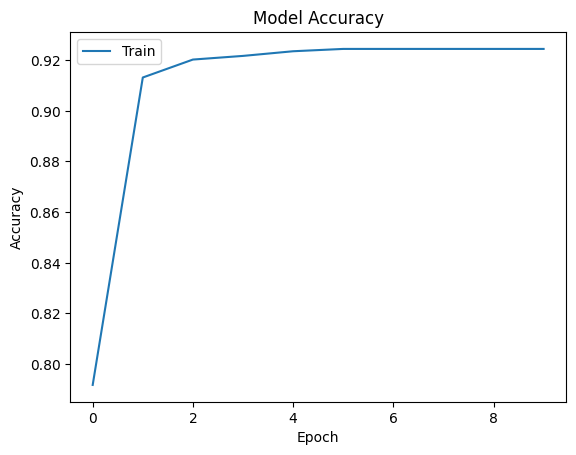

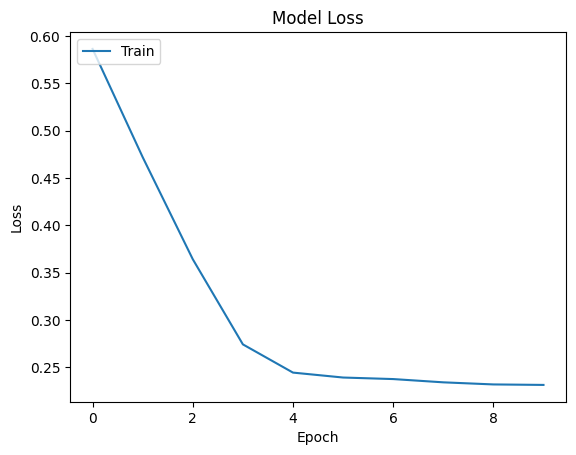

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7568 - loss: 0.5480
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9610 - loss: 0.2001
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9856 - loss: 0.0657
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9908 - loss: 0.0327
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9949 - loss: 0.0181
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9965 - loss: 0.0152
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9987 - loss: 0.0093
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9990 - loss: 0.0083
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9984 - loss: 0.0077
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9990 - loss: 0.0056


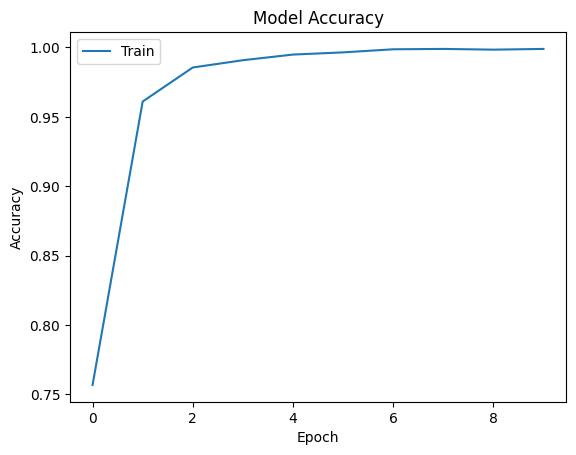

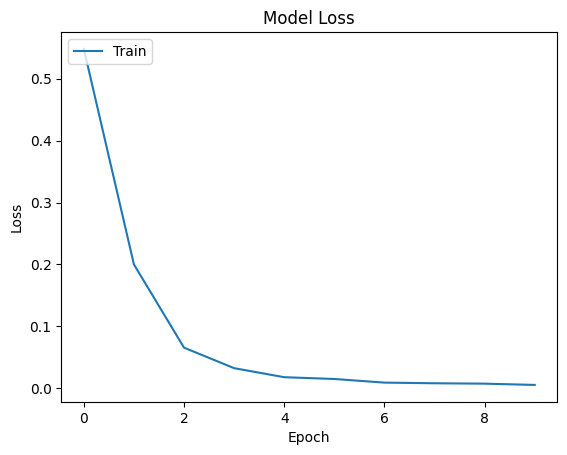

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.6834 - loss: 0.6635
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8096 - loss: 0.5813
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8714 - loss: 0.4430
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9150 - loss: 0.3136
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9221 - loss: 0.2627
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9243 - loss: 0.2457
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9242 - loss: 0.2430
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9239 - loss: 0.2406
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9242 - loss: 0.2407
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9243 - loss: 0.2396


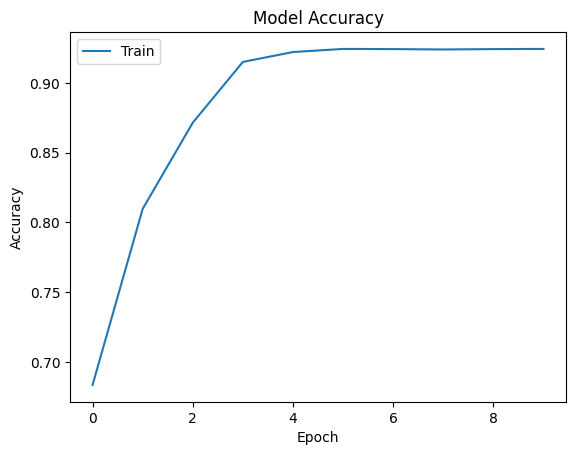

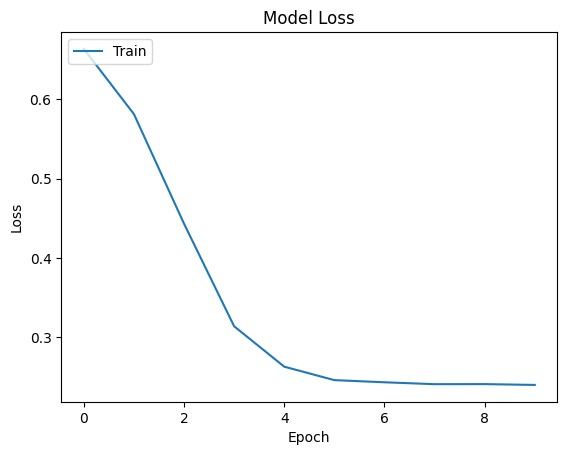

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4504 - loss: 0.8934 
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5585 - loss: 0.6719
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6035 - loss: 0.6605
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5947 - loss: 0.6493
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6305 - loss: 0.6036
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6399 - loss: 0.5302
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7128 - loss: 0.4743
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8937 - loss: 0.3931
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9751 - loss: 0.2909
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9805 - loss: 0.2344


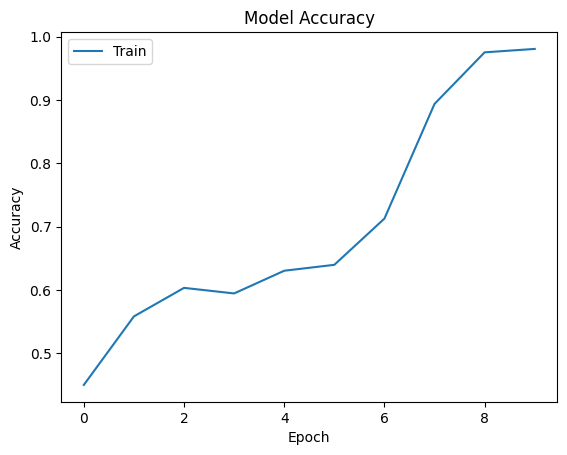

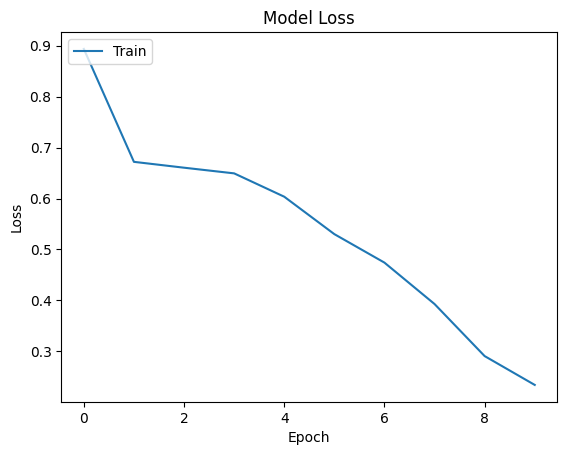

['loss', 'compile_metrics']
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained


In [26]:

## Comment next 2 blocks if loading pre-trained models
## Execute them if training new models

model_gru = GRU_model(X_train.shape[1]) #quando treina novo modelo
model_cnn = CNN_model(X_train.shape[1])
model_lstm = LSTM_model(X_train.shape[1])
model_dnn = DNN_model(X_train.shape[1])
model_svm = SVM()
model_lr = LR()
model_gd = GD()
model_knn = kNN()
 
model_gru = compile_train(model_gru,format_3d(X_train),y_train)  #quando treina novo modelo, ou retreina
model_cnn = compile_train(model_cnn,format_3d(X_train),y_train)
model_lstm = compile_train(model_lstm,format_3d(X_train),y_train)
model_dnn = compile_train(model_dnn,X_train,y_train)
model_svm = compile_train(model_svm,X_train,y_train,False)
model_lr = compile_train(model_lr,X_train,y_train,False)
model_gd = compile_train(model_gd,X_train,y_train,False)
model_knn = compile_train(model_knn,X_train,y_train,False)

## Comment next 2 blocks if training new models
## Execute them if loading pre-trained models

# model_gru = load_model('GRU20-32-b256') #when loading previously saved trained model and weights
# model_cnn = load_model('CNN5-3cam-b2560')
# model_lstm = load_model('LSTM5-32-b256')
# model_dnn = load_model('DNN5-2560')
# model_svm = load_Sklearn('SVM') 
# model_lr = load_Sklearn('LR')
# model_gd = load_Sklearn('GD')
# model_knn = load_Sklearn('kNN-1viz')

# model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) #qdo carrega modelo salvo
# model_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model_dnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# Testing CIC-DDoS2019 

In [27]:
results = pd.DataFrame(columns=['Method','Accuracy','Precision','Recall', 'F1_Score', 'Average','Normal_Detect_Rate','Atk_Detect_Rate'])

### GRU

In [28]:
y_pred = model_gru.predict(format_3d(X_test)) 

y_pred = y_pred.round()
 
acc, prec, rec, f1, avrg = testes(model_gru,format_3d(X_test),y_test,y_pred)

norm, atk = test_normal_atk(y_test,y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'GRU', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)

def test_normal_atk(y_test, y_pred):
    df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
    
    normal = (df['y_test'] == 0).sum()
    atk = (df['y_test'] == 1).sum()
    
    wrong = df[df['y_test'] != df['y_pred']]
    wrong_grouped = wrong.groupby('y_test').count()
    
    # Berapa yang salah per kelas (0 kalau tidak ada yang salah)
    wrong_normal = wrong_grouped.loc[0]['y_pred'] if 0 in wrong_grouped.index else 0
    wrong_atk = wrong_grouped.loc[1]['y_pred'] if 1 in wrong_grouped.index else 0
    
    normal_detect_rate = (normal - wrong_normal) / normal if normal > 0 else 0
    atk_detect_rate = (atk - wrong_atk) / atk if atk > 0 else 0
    
    return normal_detect_rate, atk_detect_rate

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9697 - loss: 0.1852
[0.18521007895469666, 0.9696969985961914]

Accuracy
0.9696969696969697

Precision
0.9678089304257529

Recall
0.9967914438502674

F1 Score
0.982086406743941

Average (acc, prec, rec, f1)
0.9790959376792328


/tmp/ipykernel_58/1665266170.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normal_detect_rate = (normal - wrong.groupby('y_test').count().iloc[0][0]) / normal
/tmp/ipykernel_58/1665266170.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  atk_detect_rate = (atk - wrong.groupby('y_test').count().iloc[1][0]) / atk
/tmp/ipykernel_58/1371564169.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries 

### CNN

In [29]:
y_pred = model_cnn.predict(format_3d(X_test))
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

acc, prec, rec, f1, avrg = testes(model_cnn, format_3d(X_test), y_test, y_pred)
norm, atk = test_normal_atk(y_test, y_pred)

results = pd.concat([results, pd.DataFrame([{'Method': 'CNN', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9866 - loss: 0.0588
[0.05878002569079399, 0.9866310358047485]

Accuracy
0.9866310160427807

Precision
0.9925053533190579

Recall
0.9914438502673797

F1 Score
0.9919743178170144

Average (acc, prec, rec, f1)
0.9906386343615581


### LSTM

In [30]:
y_pred = model_lstm.predict(format_3d(X_test))
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()


y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_lstm, format_3d(X_test), y_test, y_pred)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'LSTM', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9697 - loss: 0.1846
[0.18456877768039703, 0.9696969985961914]

Accuracy
0.9696969696969697

Precision
0.9687825182101977

Recall
0.9957219251336898

F1 Score
0.9820675105485233

Average (acc, prec, rec, f1)
0.9790672308973452


### DNN

In [31]:
y_pred = model_dnn.predict(X_test)
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_dnn, X_test, y_test, y_pred)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'DNN', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.3482
[0.3482160270214081, 0.832442045211792]

Accuracy
0.8324420677361853

Precision
0.9986648865153538

Recall
0.8

F1 Score
0.8883610451306413

Average (acc, prec, rec, f1)
0.8798669998455451


### SVM

In [32]:
y_pred = model_svm.predict(X_test)
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_svm, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'SVM', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)



Accuracy
0.9955436720142602

Precision
0.9978586723768736

Recall
0.9967914438502674

F1 Score
0.9973247726056714

Average (acc, prec, rec, f1)
0.9968796402117682


### LR

In [33]:
y_pred = model_lr.predict(X_test)
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_lr, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'LR', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)



Accuracy
0.9955436720142602

Precision
0.9978586723768736

Recall
0.9967914438502674

F1 Score
0.9973247726056714

Average (acc, prec, rec, f1)
0.9968796402117682


### GB

In [34]:
y_pred = model_gd.predict(X_test)
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_gd, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'GB', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)



Accuracy
0.9955436720142602

Precision
0.9978586723768736

Recall
0.9967914438502674

F1 Score
0.9973247726056714

Average (acc, prec, rec, f1)
0.9968796402117682


### kNN

In [35]:
y_pred = model_knn.predict(X_test)
y_pred = y_pred.round().flatten()  # <-- tambah .flatten()

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_knn, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'kNN', 'Accuracy': acc, 'Precision': prec, 
                                             'F1_Score': f1, 'Recall': rec, 'Average': avrg, 
                                             'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk}])], 
                     ignore_index=True)



Accuracy
0.9982174688057041

Precision
0.9989304812834224

Recall
0.9989304812834224

F1 Score
0.9989304812834224

Average (acc, prec, rec, f1)
0.9987522281639929


# Discussion and Results

Showing the table 'results', containing the performance metrics outcomes for each method.

In [36]:
results

,Method,Accuracy,Precision,Recall,F1_Score,Average,Normal_Detect_Rate,Atk_Detect_Rate
0,GRU,0.969697,0.967809,0.996791,0.982086,0.979096,0.834225,0.996791
1,CNN,0.986631,0.992505,0.991444,0.991974,0.990639,0.962567,0.991444
2,LSTM,0.969697,0.968783,0.995722,0.982068,0.979067,0.839572,0.995722
3,DNN,0.832442,0.998665,0.800000,0.888361,0.879867,0.994652,0.800000
4,SVM,0.995544,0.997859,0.996791,0.997325,0.996880,0.989305,0.996791
5,LR,0.995544,0.997859,0.996791,0.997325,0.996880,0.989305,0.996791
6,GB,0.995544,0.997859,0.996791,0.997325,0.996880,0.989305,0.996791
7,kNN,0.998217,0.998930,0.998930,0.998930,0.998752,0.994652,0.998930


**Classification Metrics:**
* Accuracy
* Precision
* Recall
* F1 Measure (F1 Score)

Showing performance outcomes of the methods: 
* GRU
* DNN
* SVM
* LR
* GB
* kNN

LSTM and CNN were separated for visualization improvement.

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

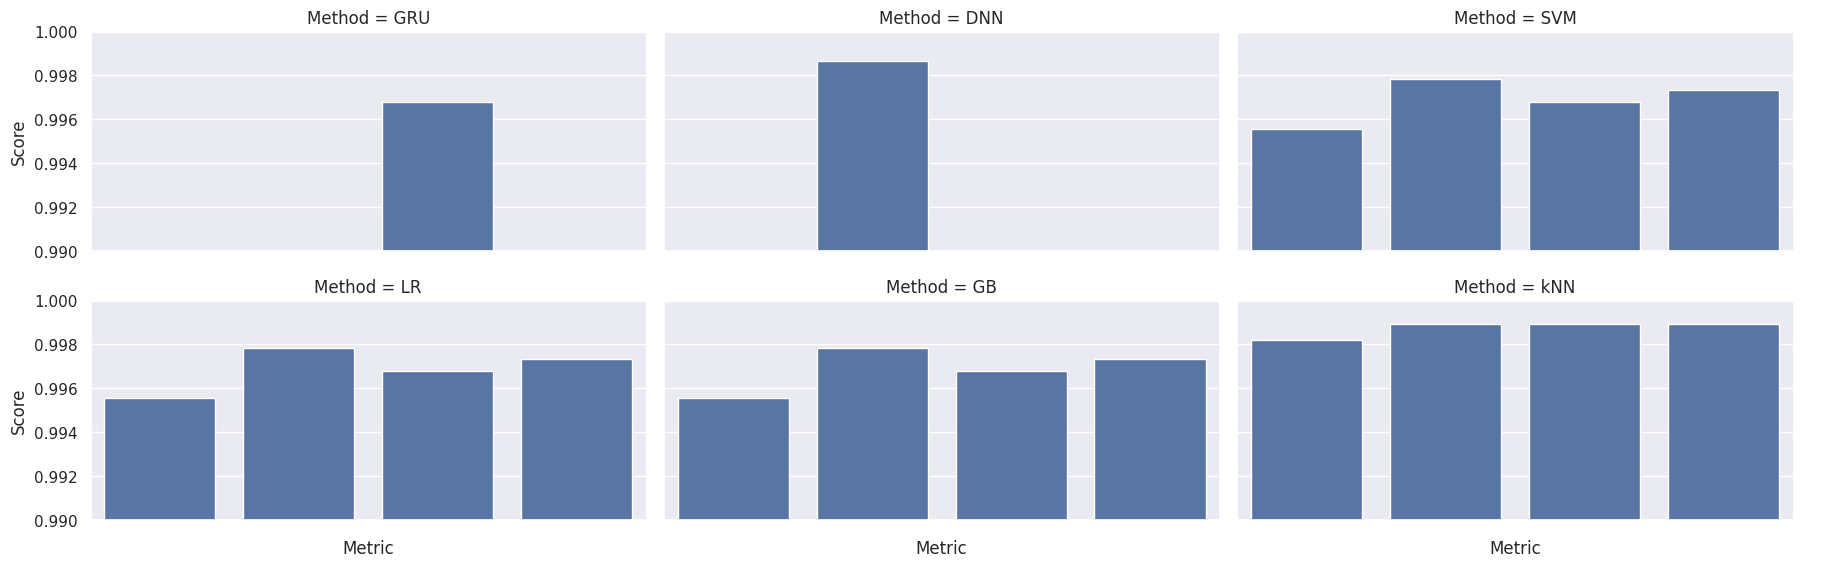

In [38]:
cols = ['Method', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
plot_data = results[cols].query('Method != "LSTM" and Method != "CNN"')
plot_data = plot_data.melt(id_vars='Method', var_name='Metric', value_name='Score')

ax = sns.catplot(data=plot_data, x='Metric', y='Score', col='Method', col_wrap=3, kind='bar', height=3, aspect=2)
ax.set(ylim=(0.99, 1))
ax.set_xticklabels(rotation=45)

> As observed, the evaluated methods achieved good performance outcomes close to 1. As the evaluated methods achieved similar outcomes, a more specific analysis should be performed.

Showing results of the LSTM and CNN methods.

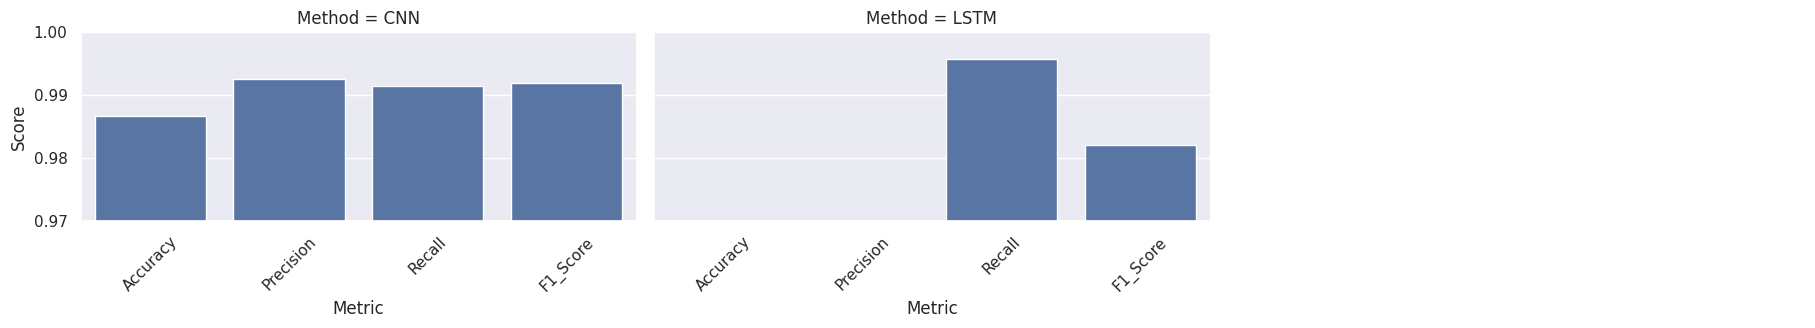

In [39]:
cols = ['Method', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
plot_data = results[cols].query('Method == "LSTM" or Method == "CNN"')
plot_data = plot_data.melt(id_vars='Method', var_name='Metric', value_name='Score')

ax = sns.catplot(data=plot_data, x='Metric', y='Score', col='Method', col_wrap=3, kind='bar', height=3, aspect=2)
ax.set(ylim=(0.97, 1))
ax.set_xticklabels(rotation=45)

> CNN and LSTM fared worse between the tested approaches. However, these methods achieved performance metrics above 97%, which is a relatively good outcome. 

**Average of the Metrics**

Plotting the Average of the previously mentioned performance metrics to summarize the method's results. 

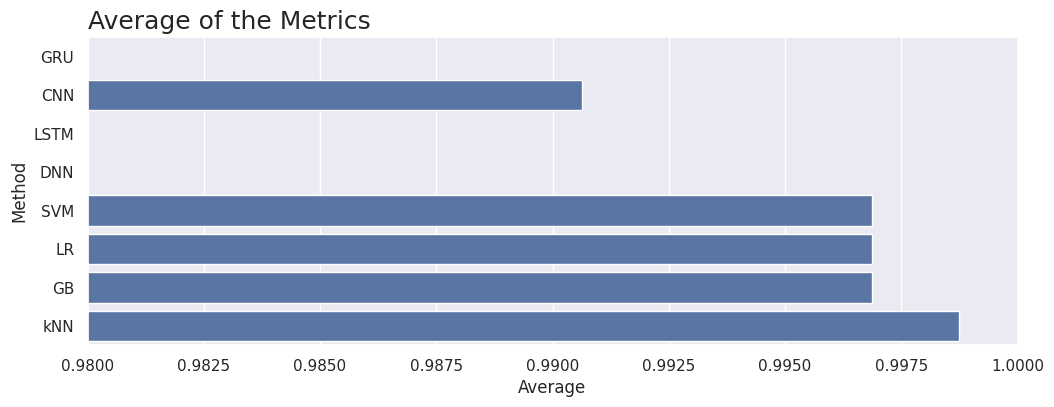

In [40]:
plt.figure(figsize=(12, 4))
ax = sns.barplot(data=results, y='Method', x='Average')
ax.set(xlim=(0.98, 1))
ax.set_title('Average of the Metrics', fontsize=18, loc='left')
# If you want to modify the x-tick labels, uncomment the line below and provide the desired labels
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Example for rotating labels
ax = ax
plt.show()


> As observed, on average, kNN fared slightly better compared to GB, LR, SVM, and GRU, which, in turn, achieved very similar results. However, these methods performed nearly 99.9%, which is considered a good classification outcome. 

**Detection rate of Normal and Attack flow records**

The following plot shows the results of each method for classifying normal and attack flow records.

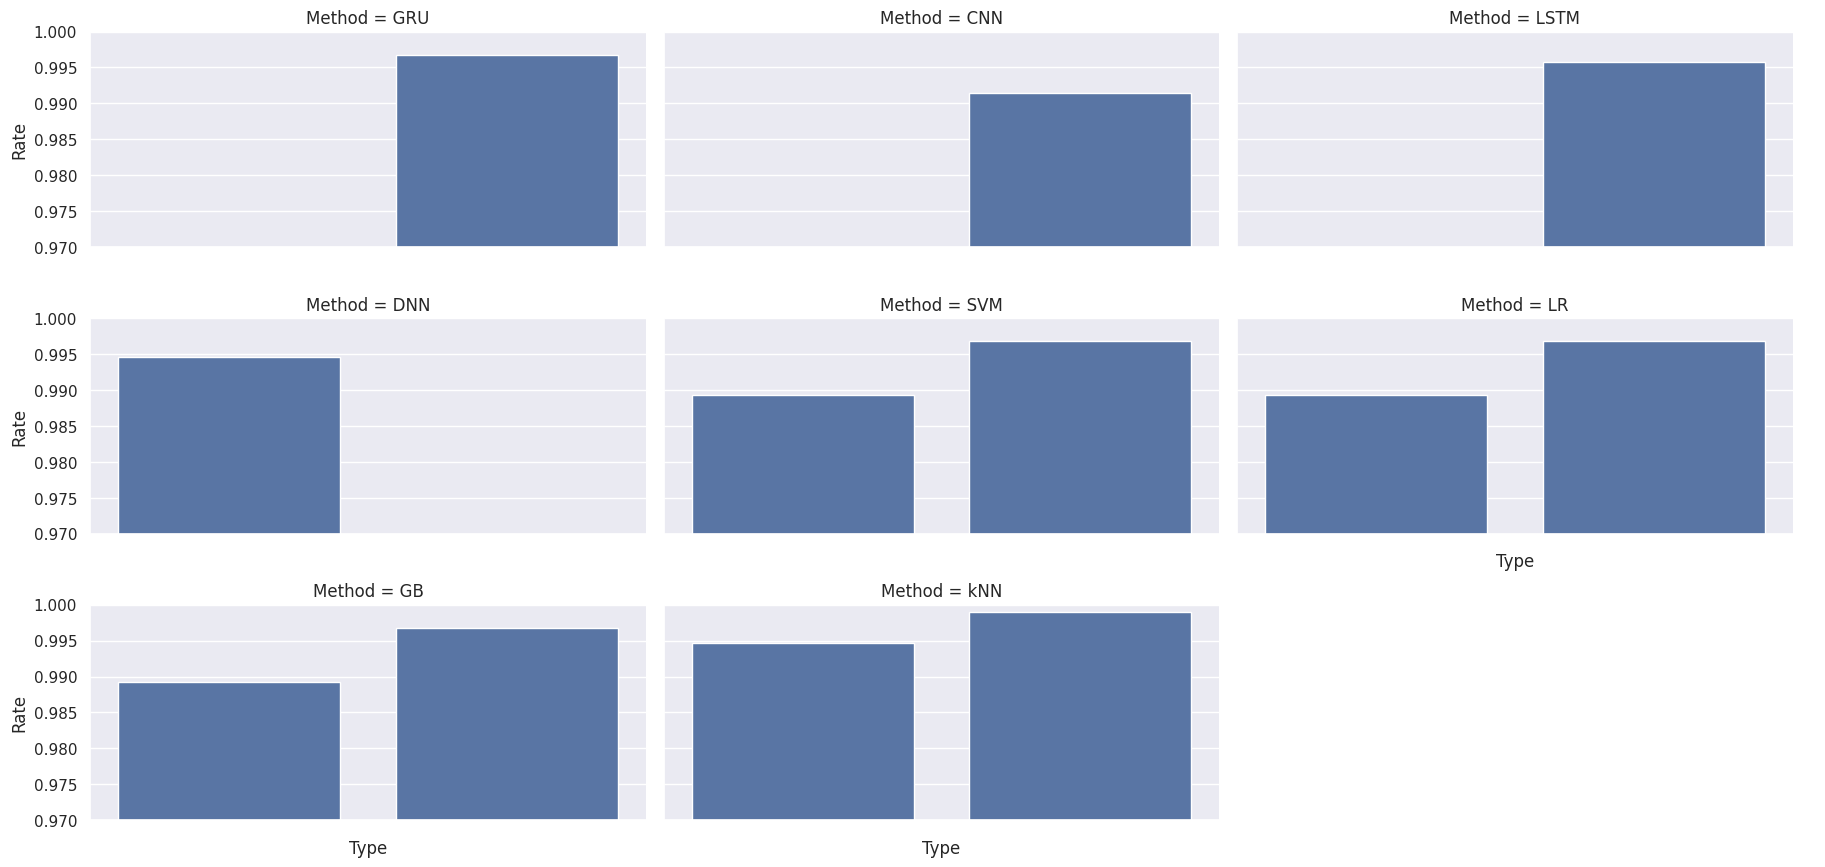

In [41]:
plot_data = results[['Method', 'Normal_Detect_Rate', 'Atk_Detect_Rate']].melt(id_vars='Method', var_name='Type', value_name='Rate')

ax = sns.catplot(data=plot_data, x='Type', y='Rate', col='Method', col_wrap=3, kind='bar', height=3, aspect=2)
ax.set(ylim=(0.97, 1))
ax.set_xticklabels(rotation=45)

> kNN achieved the best classification outcomes. 

> GRU showed the most balanced approach regarding classifying normal and attack flows. 

> Although CNN achieved a relatively good classification of attacks, the classification of normal record flows was low compared to other methods. This result can explain the Accuracy rate of this method. This situation also occurs with the LSTM method, which achieved a good classification rate for normal flows and a low classification rate for attack ones. 

In [42]:
!pip install tf2onnx -q
import tensorflow as tf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 23.3 MB/s eta 0:00:0000:01


In [43]:
import os

KERAS_DIR = '/kaggle/working/models_keras'
ONNX_DIR  = '/kaggle/working/models_onnx'
os.makedirs(KERAS_DIR, exist_ok=True)
os.makedirs(ONNX_DIR, exist_ok=True)

keras_models = [
    ('gru',  model_gru,  True),
    ('lstm', model_lstm, True),
    ('cnn',  model_cnn,  True),
    ('dnn',  model_dnn,  False),
]

for name, model, is_3d in keras_models:
    # --- Simpan .keras ---
    keras_path = f'{KERAS_DIR}/{name}.keras'
    model.save(keras_path)
    print(f'[keras] {name} saved → {keras_path}')

    # --- Export SavedModel dulu ---
    saved_path = f'/tmp/{name}_saved'
    model.export(saved_path)

    # --- Konversi via CLI ---
    onnx_path = f'{ONNX_DIR}/{name}.onnx'
    os.system(f'python -m tf2onnx.convert --saved-model {saved_path} --opset 13 --output {onnx_path}')
    
    if os.path.exists(onnx_path):
        print(f'[onnx]  {name} saved → {onnx_path}')
    else:
        print(f'[onnx]  {name} GAGAL dikonversi!')

print('\nSelesai!')

[keras] gru saved → /kaggle/working/models_keras/gru.keras
INFO:tensorflow:Assets written to: /tmp/gru_saved/assets


INFO:tensorflow:Assets written to: /tmp/gru_saved/assets


Saved artifact at '/tmp/gru_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 82, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132285959037264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959036496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959039184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959039568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959038992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959039952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285959042448: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-06-24 11:36:57.134428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782301017.160322     716 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782301017.170431     716 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782301017.191176     716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301017.191232     716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301017.191235     716 computation_placer.cc:177] computation placer alr

[onnx]  gru saved → /kaggle/working/models_onnx/gru.onnx
[keras] lstm saved → /kaggle/working/models_keras/lstm.keras
INFO:tensorflow:Assets written to: /tmp/lstm_saved/assets


...

[onnx]  cnn saved → /kaggle/working/models_onnx/cnn.onnx
[keras] dnn saved → /kaggle/working/models_keras/dnn.keras
INFO:tensorflow:Assets written to: /tmp/dnn_saved/assets


INFO:tensorflow:Assets written to: /tmp/dnn_saved/assets


Saved artifact at '/tmp/dnn_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 82), dtype=tf.float32, name='keras_tensor_78')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132285955375376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955378832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955379408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955379216: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-06-24 11:37:24.172403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782301044.198344     894 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782301044.205828     894 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782301044.225602     894 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301044.225644     894 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301044.225648     894 computation_placer.cc:177] computation placer alr

[onnx]  dnn saved → /kaggle/working/models_onnx/dnn.onnx

Selesai!


In [44]:
# ============================================================
# CELL: Export sklearn models ke .pkl
# ============================================================
import pickle

SKLEARN_DIR = '/kaggle/working/models_sklearn'
os.makedirs(SKLEARN_DIR, exist_ok=True)

sklearn_models = [
    ('svm', model_svm),
    ('lr',  model_lr),
    ('gd',  model_gd),
    ('knn', model_knn),
]

for name, model in sklearn_models:
    path = f'{SKLEARN_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'[pkl] {name} saved → {path}')

print('\nSemua sklearn model berhasil diekspor!')

[pkl] svm saved → /kaggle/working/models_sklearn/svm.pkl
[pkl] lr saved → /kaggle/working/models_sklearn/lr.pkl
[pkl] gd saved → /kaggle/working/models_sklearn/gd.pkl
[pkl] knn saved → /kaggle/working/models_sklearn/knn.pkl

Semua sklearn model berhasil diekspor!


In [45]:
!pip install onnxruntime onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 78.6 MB/s eta 0:00:00:00:0100:01


In [46]:
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout

def rebuild_gru_cpu(original_model):
    new_model = Sequential([
        GRU(32, input_shape=(X_test.shape[1], 1), implementation=1),
        Dropout(0.0),  # placeholder agar jumlah layer sama
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    new_model.set_weights(original_model.get_weights())
    return new_model

def rebuild_lstm_cpu(original_model):
    new_model = Sequential([
        LSTM(32, input_shape=(X_test.shape[1], 1), implementation=1),
        Dropout(0.0),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    new_model.set_weights(original_model.get_weights())
    return new_model

# Rebuild
model_gru_cpu  = rebuild_gru_cpu(model_gru)
model_lstm_cpu = rebuild_lstm_cpu(model_lstm)

# Re-export
for name, model in [('gru', model_gru_cpu), ('lstm', model_lstm_cpu)]:
    saved_path = f'/tmp/{name}_cpu_saved'
    model.export(saved_path)
    onnx_path = f'{ONNX_DIR}/{name}.onnx'
    os.system(f'python -m tf2onnx.convert --saved-model {saved_path} --opset 13 --output {onnx_path}')
    print(f'[onnx] {name} re-exported → {onnx_path}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


INFO:tensorflow:Assets written to: /tmp/gru_cpu_saved/assets


INFO:tensorflow:Assets written to: /tmp/gru_cpu_saved/assets


Saved artifact at '/tmp/gru_cpu_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 82, 1), dtype=tf.float32, name='keras_tensor_82')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132285955384784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955381520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955383056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955381904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955375568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285886629648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955382096: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-06-24 11:37:37.838627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782301057.863968     952 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782301057.871527     952 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782301057.890743     952 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301057.890793     952 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301057.890796     952 computation_placer.cc:177] computation placer alr

[onnx] gru re-exported → /kaggle/working/models_onnx/gru.onnx
INFO:tensorflow:Assets written to: /tmp/lstm_cpu_saved/assets


INFO:tensorflow:Assets written to: /tmp/lstm_cpu_saved/assets


Saved artifact at '/tmp/lstm_cpu_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 82, 1), dtype=tf.float32, name='keras_tensor_87')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132285955384976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955386128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955376720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955381328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955383440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285955383632: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-06-24 11:37:46.429331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782301066.454726    1015 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782301066.462416    1015 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782301066.482505    1015 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301066.482553    1015 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782301066.482556    1015 computation_placer.cc:177] computation placer alr

[onnx] lstm re-exported → /kaggle/working/models_onnx/lstm.onnx


In [47]:
"""
verify_onnx.py
Verifikasi semua model ONNX hasil export dari notebook DDoS.

Cara pakai:
    python verify_onnx.py

Pastikan onnxruntime sudah terinstall:
    pip install onnxruntime onnx numpy
"""

import os
import numpy as np
import onnx
import onnxruntime as ort

ONNX_DIR = '/kaggle/working/models_onnx'   # sesuaikan path kalau beda

# Model yang diekspor + apakah butuh input 3D
MODELS = [
    ('gru',  True),
    ('lstm', True),
    ('cnn',  True),
    ('dnn',  False),
]

# Dimensi fitur (sesuaikan dengan jumlah kolom X_test di notebook)
NUM_FEATURES = 82  # ubah kalau beda

INPUT_2D = np.random.rand(1, NUM_FEATURES).astype(np.float32)
INPUT_3D = np.random.rand(1, NUM_FEATURES, 1).astype(np.float32)



def check_onnx_model(path: str) -> bool:
    """Validasi struktur ONNX model."""
    try:
        model = onnx.load(path)
        onnx.checker.check_model(model)
        print(f"  [✓] ONNX check passed")
        return True
    except onnx.checker.ValidationError as e:
        print(f"  [✗] ONNX check FAILED: {e}")
        return False


def run_inference(path: str, input_data: np.ndarray) -> bool:
    """Jalankan inferensi ONNX dan cek output."""
    try:
        sess = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
        input_name = sess.get_inputs()[0].name
        output = sess.run(None, {input_name: input_data})
        pred = output[0]
        print(f"  [✓] Inference OK — output shape: {pred.shape}, value: {pred.flatten()[:5]}")
        return True
    except Exception as e:
        print(f"  [✗] Inference FAILED: {e}")
        return False


def main():
    print("=" * 55)
    print(" ONNX Model Verification")
    print("=" * 55)

    results = {}

    for name, is_3d in MODELS:
        path = os.path.join(ONNX_DIR, f'{name}.onnx')
        print(f"\n[{name.upper()}] → {path}")

        if not os.path.exists(path):
            print(f"  [✗] File tidak ditemukan: {path}")
            results[name] = False
            continue

        file_size_kb = os.path.getsize(path) / 1024
        print(f"  File size : {file_size_kb:.1f} KB")

        ok_check  = check_onnx_model(path)
        input_data = INPUT_3D if is_3d else INPUT_2D
        ok_infer  = run_inference(path, input_data)

        results[name] = ok_check and ok_infer

    # Ringkasan
    print("\n" + "=" * 55)
    print(" Ringkasan")
    print("=" * 55)
    all_ok = True
    for name, ok in results.items():
        status = "✓ PASS" if ok else "✗ FAIL"
        print(f"  {name.upper():<6} : {status}")
        if not ok:
            all_ok = False

    print("=" * 55)
    if all_ok:
        print(" Semua model ONNX berhasil diverifikasi!")
    else:
        print(" Ada model yang gagal, cek log di atas.")
    print("=" * 55)


if __name__ == '__main__':
    main()

 ONNX Model Verification

[GRU] → /kaggle/working/models_onnx/gru.onnx
  File size : 32.4 KB
  [✓] ONNX check passed
  [✓] Inference OK — output shape: (1, 1), value: [0.63482326]

[LSTM] → /kaggle/working/models_onnx/lstm.onnx
  File size : 34.5 KB
  [✓] ONNX check passed
  [✓] Inference OK — output shape: (1, 1), value: [0.5594693]

[CNN] → /kaggle/working/models_onnx/cnn.onnx
  File size : 147.0 KB
  [✓] ONNX check passed
  [✓] Inference OK — output shape: (1, 1), value: [0.00789112]

[DNN] → /kaggle/working/models_onnx/dnn.onnx
  File size : 2.4 KB
  [✓] ONNX check passed
  [✓] Inference OK — output shape: (1, 1), value: [0.48946744]

 Ringkasan
  GRU    : ✓ PASS
  LSTM   : ✓ PASS
  CNN    : ✓ PASS
  DNN    : ✓ PASS
 Semua model ONNX berhasil diverifikasi!


In [48]:
model_gru.summary()
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,105 (43.38 KB)

 Trainable params: 3,701 (14.46 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.01 KB)

 Trainable params: 4,693 (18.33 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,388 (36.68 KB)